<a href="https://colab.research.google.com/github/RodrigoCasanova/Backend/blob/main/BIY7121_Entrega3_G1_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 3: Modelos de Clasificación y Segmentación
**Asignatura:** BIY7121 - Minería de Datos - **Grupo:** 1

**Autores:** Rodrigo Casanova, José Vásquez, Samuel Acuña

**Correos:** rodr.casanova@duocuc.cl, jo.vasquezp@duocuc.cl, sam.acuna@duocuc.cl

**Fecha:** Junio 2026

**Versión:** 2.0



## Importación de librerías


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
sb.set_style("whitegrid")
from sklearn.inspection import permutation_importance
!pip install kneed -q
from kneed import KneeLocator

## Contexto y objetivo del proyecto

Una empresa de construcción que opera en **Concepción, Valdivia, Temuco y Punta Arenas** busca
optimizar la planificación de sus obras considerando las condiciones climáticas. A partir de
variables meteorológicas (temperatura, humedad, nubosidad, viento, horas de sol, etc.) se busca:

1. **Clasificación:** predecir si una hora determinada será **lluviosa** (`is_rainy_hour`), de
   forma que el modelo sea **funcional** (solo usa información disponible al momento de la
   predicción, sin variables futuras ni fuga de datos).
2. **Segmentación:** agrupar las observaciones climáticas en **perfiles operativos** que permitan
   tomar decisiones de planificación.

> **Nota sobre la variable objetivo:** la rúbrica la nombra `is_rain_hour`; en el dataset la
> columna real es **`is_rainy_hour`**, que es la que se utiliza en todo el desarrollo.


## Carga del conjunto de datos


In [2]:
!wget -q https://raw.githubusercontent.com/RodrigoCasanova/Mineria_de_datos_grupo1/refs/heads/main/datos/data_clima_2025_final.csv
data = pd.read_csv("data_clima_2025_final.csv", sep=",", low_memory=False)
print("Dimensiones:", data.shape)
data.head()

Dimensiones: (33024, 15)


,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,rain,is_day,sunshine_duration,Localidad,latitud,longitud,is_rainy_hour
0,2025-01-01 03:00:00+00:00,15.1,72.053330,13.451475,0.0,0.0,11.609651,187.12492,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
1,2025-01-01 04:00:00+00:00,14.9,64.437440,12.787600,0.0,0.0,11.341428,179.09064,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
2,2025-01-01 05:00:00+00:00,14.4,63.023464,12.131762,0.0,0.0,11.032987,174.38250,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
3,2025-01-01 06:00:00+00:00,13.9,65.991730,11.714258,0.0,0.0,10.805999,178.09090,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0
4,2025-01-01 07:00:00+00:00,13.4,70.770430,11.426943,0.0,0.0,10.299397,185.01303,0.0,0.0,0.0,"Concepción, Chile",-36.82707,-73.050206,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33024 entries, 0 to 33023
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  33024 non-null  object 
 1   temperature_2m        33024 non-null  float64
 2   relative_humidity_2m  33024 non-null  float64
 3   apparent_temperature  33024 non-null  float64
 4   precipitation         33024 non-null  float64
 5   cloud_cover           33024 non-null  float64
 6   wind_speed_10m        33024 non-null  float64
 7   wind_direction_10m    33024 non-null  float64
 8   rain                  33024 non-null  float64
 9   is_day                33024 non-null  float64
 10  sunshine_duration     33024 non-null  float64
 11  Localidad             33024 non-null  object 
 12  latitud               33024 non-null  float64
 13  longitud              33024 non-null  float64
 14  is_rainy_hour         33024 non-null  int64  
dtypes: float64(12), int

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,33024.0,10.644075,5.213359,-5.100000,7.050000,10.400000,13.700000,31.750000
relative_humidity_2m,33024.0,79.042842,16.228987,15.230701,68.349886,82.217838,92.891105,100.000000
apparent_temperature,33024.0,8.337603,6.350746,-8.741941,3.876656,8.232820,12.350445,32.108310
precipitation,33024.0,0.138981,0.582210,0.000000,0.000000,0.000000,0.000000,13.200000
cloud_cover,33024.0,62.114977,41.871036,0.000000,13.000000,88.000000,100.000000,100.000000
wind_speed_10m,33024.0,11.930189,8.474665,0.000000,5.649248,9.940824,15.882896,65.250920
wind_direction_10m,33024.0,205.227225,101.410042,0.367278,139.531913,229.398790,284.036250,360.000000
rain,33024.0,0.136601,0.577866,0.000000,0.000000,0.000000,0.000000,13.200000
is_day,33024.0,0.495882,0.499991,0.000000,0.000000,0.000000,1.000000,1.000000
sunshine_duration,33024.0,1221.216663,1650.360797,0.000000,0.000000,0.000000,3600.000000,3600.000000


## Fase 3 - Preparación de datos

Antes de modelar revisamos duplicados, nulos e inconsistencias y derivamos las variables
temporales necesarias para que el modelo sea **funcional**.


In [5]:
# Duplicados
print("Filas duplicadas:", data.duplicated().sum())

Filas duplicadas: 0


In [6]:
# Valores nulos por columna
data.isnull().sum()

,0
date,0
temperature_2m,0
relative_humidity_2m,0
apparent_temperature,0
precipitation,0
cloud_cover,0
wind_speed_10m,0
wind_direction_10m,0
rain,0
is_day,0


### Derivación de la hora y el mes (modelo funcional)

La columna `date` viene en **UTC**. Para que la hora represente correctamente el ciclo diario
**local** de cada localidad, la convertimos a la zona horaria de Chile (`America/Santiago`) y
recién entonces extraemos `hora` y `mes`. Estas variables son conocidas al momento de predecir,
por lo que **no introducen fuga de datos**.


In [7]:
data["date"] = pd.to_datetime(data["date"], utc=True)
data["date_local"] = data["date"].dt.tz_convert("America/Santiago")

data["hora"] = data["date_local"].dt.hour
data["mes"]  = data["date_local"].dt.month

data[["date", "date_local", "hora", "mes"]].head()


,date,date_local,hora,mes
0,2025-01-01 03:00:00+00:00,2025-01-01 00:00:00-03:00,0,1
1,2025-01-01 04:00:00+00:00,2025-01-01 01:00:00-03:00,1,1
2,2025-01-01 05:00:00+00:00,2025-01-01 02:00:00-03:00,2,1
3,2025-01-01 06:00:00+00:00,2025-01-01 03:00:00-03:00,3,1
4,2025-01-01 07:00:00+00:00,2025-01-01 04:00:00-03:00,4,1


### Tratamiento de inconsistencias


In [8]:
def tratar_inconsistencias(df):
    df = df.copy()

    # 1. Valores negativos en variables donde no deberían existir
    columnas_no_negativas = [
        "precipitation", "rain", "cloud_cover",
        "wind_speed_10m", "sunshine_duration", "relative_humidity_2m"
    ]
    for col in columnas_no_negativas:
        if col in df.columns:
            n = (df[col] < 0).sum()
            if n > 0:
                print(f"{col}: {n} valores negativos reemplazados por NaN")
                df[col] = df[col].where(df[col] >= 0, np.nan)

    # 2. Humedad y nubosidad fuera de rango [0, 100]
    for col in ["relative_humidity_2m", "cloud_cover"]:
        if col in df.columns:
            mask = (df[col] < 0) | (df[col] > 100)
            if mask.sum() > 0:
                print(f"{col}: {mask.sum()} valores fuera de rango reemplazados por NaN")
                df.loc[mask, col] = np.nan

    # 3. Dirección del viento fuera de rango [0, 360]
    if "wind_direction_10m" in df.columns:
        mask = (df["wind_direction_10m"] < 0) | (df["wind_direction_10m"] > 360)
        if mask.sum() > 0:
            print(f"wind_direction_10m: {mask.sum()} valores fuera de rango reemplazados por NaN")
            df.loc[mask, "wind_direction_10m"] = np.nan

    # 4. Variables binarias fuera de {0, 1}
    for col in ["is_day", "is_rainy_hour"]:
        if col in df.columns:
            mask = ~df[col].isin([0, 1])
            if mask.sum() > 0:
                print(f"{col}: {mask.sum()} valores no binarios reemplazados por NaN")
                df.loc[mask, col] = np.nan

    return df

data = tratar_inconsistencias(data)
print("Tratamiento de inconsistencias finalizado.")


Tratamiento de inconsistencias finalizado.


### Interpretación

Se aplicaron reglas propias del contexto climático: humedad y nubosidad entre 0 y 100, dirección
del viento entre 0 y 360 grados, y variables binarias restringidas a 0 y 1. Los valores fuera de
rango se reemplazan por `NaN` para que el **imputador del pipeline** los trate de forma consistente,
evitando eliminar registros completos. La temperatura negativa **no** se considera inconsistencia,
ya que es una condición climática real en zonas como Punta Arenas.


## Verificación de la variable objetivo y de la fuga de datos

Antes de elegir las variables predictoras, verificamos cómo está definida la variable objetivo.
Esto es clave para **detectar fuga de datos**.


In [9]:
# ¿is_rainy_hour coincide exactamente con que llueva (rain > 0 / precipitation > 0)?
coincide_rain = (data["is_rainy_hour"] == (data["rain"] > 0).astype(int)).mean()
coincide_prec = (data["is_rainy_hour"] == (data["precipitation"] > 0).astype(int)).mean()

print(f"is_rainy_hour == (rain > 0)          en el {coincide_rain*100:.2f}% de los casos")
print(f"is_rainy_hour == (precipitation > 0) en el {coincide_prec*100:.2f}% de los casos")

print("\nDistribución de la variable objetivo:")
print(data["is_rainy_hour"].value_counts(normalize=True).rename("proporción"))


is_rainy_hour == (rain > 0)          en el 100.00% de los casos
is_rainy_hour == (precipitation > 0) en el 99.84% de los casos

Distribución de la variable objetivo:
is_rainy_hour
0    0.815286
1    0.184714
Name: proporción, dtype: float64


### Interpretación

La variable objetivo `is_rainy_hour` es prácticamente **equivalente a `rain > 0`** (y a
`precipitation > 0`). Por lo tanto, usar `rain` o `precipitation` como predictores sería **fuga de
datos directa**: el modelo "haría trampa" mirando la respuesta. Ambas se **excluyen** del conjunto
de variables.

Además, por decisión de estrategia del equipo, **no** se utilizan `latitud` ni `longitud`: el
modelo debe apoyarse en las **condiciones meteorológicas** y en el **ciclo temporal**, no en la
identidad geográfica de la estación. También se excluye `Localidad` (identificador) y `date`
(ya resumida en `hora`/`mes`). La clase positiva (lluvia) es **minoritaria**, lo que justifica el
uso de `class_weight="balanced"` y el posterior **ajuste de threshold**.


## Transformación cíclica de hora y mes

Las variables temporales son **circulares**: las 23:00 están cerca de las 00:00, y diciembre está
cerca de enero. Representarlas con un único número rompería esa cercanía. Por eso se transforman a
pares **seno/coseno**, que preservan la distancia cíclica.


In [10]:
data["hora_sin"] = np.sin(2 * np.pi * data["hora"] / 24)
data["hora_cos"] = np.cos(2 * np.pi * data["hora"] / 24)

data["mes_sin"] = np.sin(2 * np.pi * data["mes"] / 12)
data["mes_cos"] = np.cos(2 * np.pi * data["mes"] / 12)

data[["hora", "hora_sin", "hora_cos", "mes", "mes_sin", "mes_cos"]].head()


,hora,hora_sin,hora_cos,mes,mes_sin,mes_cos
0,0,0.000000,1.000000,1,0.5,0.866025
1,1,0.258819,0.965926,1,0.5,0.866025
2,2,0.500000,0.866025,1,0.5,0.866025
3,3,0.707107,0.707107,1,0.5,0.866025
4,4,0.866025,0.500000,1,0.5,0.866025


### Interpretación

Con la transformación cíclica el modelo interpreta correctamente los ciclos **diario** (24 h) y
**estacional** (12 meses). Se usan **dos** componentes (seno y coseno) porque una sola no permite
distinguir todas las posiciones del ciclo de forma única: juntas ubican cada hora/mes en un punto
único de una circunferencia.


# Parte 1 — Modelos de clasificación

## Definición de variables predictoras y objetivo

Construimos un **modelo funcional**: solo usa información disponible en el instante de la predicción.

| Se incluye | Se excluye | Motivo de exclusión |
|---|---|---|
| temperatura, humedad, temp. aparente, nubosidad, viento (vel. y dir.), duración de sol, `is_day` | `rain`, `precipitation` | **fuga de datos** (definen el target) |
| `hora_sin/cos`, `mes_sin/cos` (cíclicas) | `latitud`, `longitud`, `Localidad` | decisión de estrategia (sin geografía) |
|  | `date` | ya resumida en `hora` y `mes` |


**Variable considerada pero descartada (nota para la defensa):** inicialmente evaluamos usar `precipitation` y `rain` por ser muy informativas, pero las **descartamos** al comprobar que **definen** el objetivo (`is_rainy_hour == rain > 0`): sería fuga de datos. Entre las variables que sí se usan, la primera candidata a eliminar sería `apparent_temperature`, por estar muy correlacionada con `temperature_2m` (redundante); lo confirmamos abajo con la importancia de variables.


In [11]:
variables_numericas = [
    "temperature_2m", "relative_humidity_2m", "apparent_temperature",
    "cloud_cover", "wind_speed_10m", "wind_direction_10m", "sunshine_duration"
]
variables_ciclicas = ["hora_sin", "hora_cos", "mes_sin", "mes_cos"]
variables_binarias = ["is_day"]

features = variables_numericas + variables_ciclicas + variables_binarias
objetivo = "is_rainy_hour"

# Quitamos filas sin objetivo
modelo_df = data.dropna(subset=[objetivo]).copy()

X = modelo_df[features]
y = modelo_df[objetivo].astype(int)

print("Predictoras:", len(features))
print("Observaciones:", X.shape[0])
print("Balance del objetivo:\n", y.value_counts(normalize=True).round(3))


Predictoras: 12
Observaciones: 33024
Balance del objetivo:
 is_rainy_hour
0    0.815
1    0.185
Name: proportion, dtype: float64


## Separación train / test

Se usa partición **estratificada** (mantiene la proporción de horas lluviosas en ambos conjuntos)
con 20% de prueba.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (26419, 12)  Test: (6605, 12)


## Pipeline de preprocesamiento

Se aplica un **`Winsorizer`** (recorte de atípicos por percentiles) a las variables numéricas para
reducir el efecto de valores extremos sin eliminar registros, seguido de imputación y escalado. Las
variables **cíclicas** ya están en rango [-1, 1] (solo se imputan), y las **binarias** pasan
directo. Todo esto vive dentro de un `ColumnTransformer`, de modo que **no hay fuga** entre train y
test (los parámetros se aprenden solo con train).


In [13]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """Recorta cada columna a los percentiles [lower, upper]."""
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.low_  = np.nanquantile(X, self.lower, axis=0)
        self.high_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.low_, self.high_)


pipe_numericas = Pipeline([
    ("winsor", Winsorizer(0.01, 0.99)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipe_ciclicas = Pipeline([
    ("imputer", SimpleImputer(strategy="mean"))
])

preprocesador = ColumnTransformer([
    ("num", pipe_numericas, variables_numericas),
    ("cyc", pipe_ciclicas, variables_ciclicas),
    ("bin", "passthrough", variables_binarias)
])
preprocesador


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('winsor', Winsorizer()),
                                                 ('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['temperature_2m', 'relative_humidity_2m',
                                  'apparent_temperature', 'cloud_cover',
                                  'wind_speed_10m', 'wind_direction_10m',
                                  'sunshine_duration']),
                                ('cyc',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 ['hora_sin', 'hora_cos', 'mes_sin',
                                  'mes_cos']),
                                ('bin', 'passthrough', ['is_day'])])

## Construcción de los 3 modelos con GridSearchCV

Cada modelo se entrena dentro de un pipeline (`preprocesador` + clasificador) y se optimiza con
**`GridSearchCV`** usando **F1** como métrica base (apropiada para clases desbalanceadas).


In [14]:
cv = 5
scoring = "f1"

# ---- LogisticRegression ----
pipe_lr = Pipeline([("prep", preprocesador),
                    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"]
}
gs_lr = GridSearchCV(pipe_lr, grid_lr, scoring=scoring, cv=cv, n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("LogisticRegression  ->", gs_lr.best_params_, " F1 CV:", round(gs_lr.best_score_, 4))


LogisticRegression  -> {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}  F1 CV: 0.5377


In [15]:
# ---- DecisionTreeClassifier ----
pipe_dt = Pipeline([("prep", preprocesador),
                    ("clf", DecisionTreeClassifier(random_state=42, class_weight="balanced"))])
grid_dt = {
    "clf__max_depth": [4, 6, 8, 10],
    "clf__min_samples_leaf": [5, 20, 50],
    "clf__criterion": ["gini", "entropy"]
}
gs_dt = GridSearchCV(pipe_dt, grid_dt, scoring=scoring, cv=cv, n_jobs=-1)
gs_dt.fit(X_train, y_train)
print("DecisionTree        ->", gs_dt.best_params_, " F1 CV:", round(gs_dt.best_score_, 4))


DecisionTree        -> {'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__min_samples_leaf': 20}  F1 CV: 0.5884


In [16]:
# ---- GaussianNB ----
# GaussianNB no admite class_weight; usamos priors=[0.5, 0.5] para compensar el
# desbalance de clases y mejorar el recall/F1 sobre la clase minoritaria (lluvia).
pipe_nb = Pipeline([("prep", preprocesador),
                    ("clf", GaussianNB(priors=[0.5, 0.5]))])
grid_nb = {
    "clf__var_smoothing": np.logspace(-11, -6, 6)
}
gs_nb = GridSearchCV(pipe_nb, grid_nb, scoring=scoring, cv=cv, n_jobs=-1)
gs_nb.fit(X_train, y_train)
print("GaussianNB          ->", gs_nb.best_params_, " F1 CV:", round(gs_nb.best_score_, 4))


GaussianNB          -> {'clf__var_smoothing': np.float64(1e-11)}  F1 CV: 0.4767


### Combinación ganadora y peor combinación (LogisticRegression)

Revisamos `cv_results_` para identificar la **mejor** y la **peor** combinación de hiperparámetros encontrada por GridSearchCV en la Regresión Logística.


In [17]:
res_lr = pd.DataFrame(gs_lr.cv_results_)
cols_lr = ["param_clf__C", "param_clf__penalty", "param_clf__solver", "mean_test_score"]
res_lr = res_lr[cols_lr].sort_values("mean_test_score", ascending=False).reset_index(drop=True)

print("MEJOR combinacion LogisticRegression:")
print(res_lr.iloc[0].to_dict())
print("\nPEOR combinacion LogisticRegression:")
print(res_lr.iloc[-1].to_dict())
print(f"\nDiferencia de F1 (CV) mejor vs peor: {res_lr['mean_test_score'].iloc[0] - res_lr['mean_test_score'].iloc[-1]:.4f}")
res_lr


MEJOR combinacion LogisticRegression:
{'param_clf__C': 10.0, 'param_clf__penalty': 'l2', 'param_clf__solver': 'lbfgs', 'mean_test_score': 0.5377049559289342}

PEOR combinacion LogisticRegression:
{'param_clf__C': 0.01, 'param_clf__penalty': 'l2', 'param_clf__solver': 'lbfgs', 'mean_test_score': 0.5351767588385591}

Diferencia de F1 (CV) mejor vs peor: 0.0025


,param_clf__C,param_clf__penalty,param_clf__solver,mean_test_score
0,10.00,l2,lbfgs,0.537705
1,1.00,l2,lbfgs,0.537334
2,0.10,l2,lbfgs,0.536160
3,0.01,l2,lbfgs,0.535177


## Comprobación del supuesto de GaussianNB (normalidad)

`GaussianNB` **asume que cada variable numérica sigue una distribución normal dentro de cada clase**.
Lo verificamos con histogramas y con el estadístico de **asimetría (skew)**; un valor cercano a 0
indica simetría tipo normal.


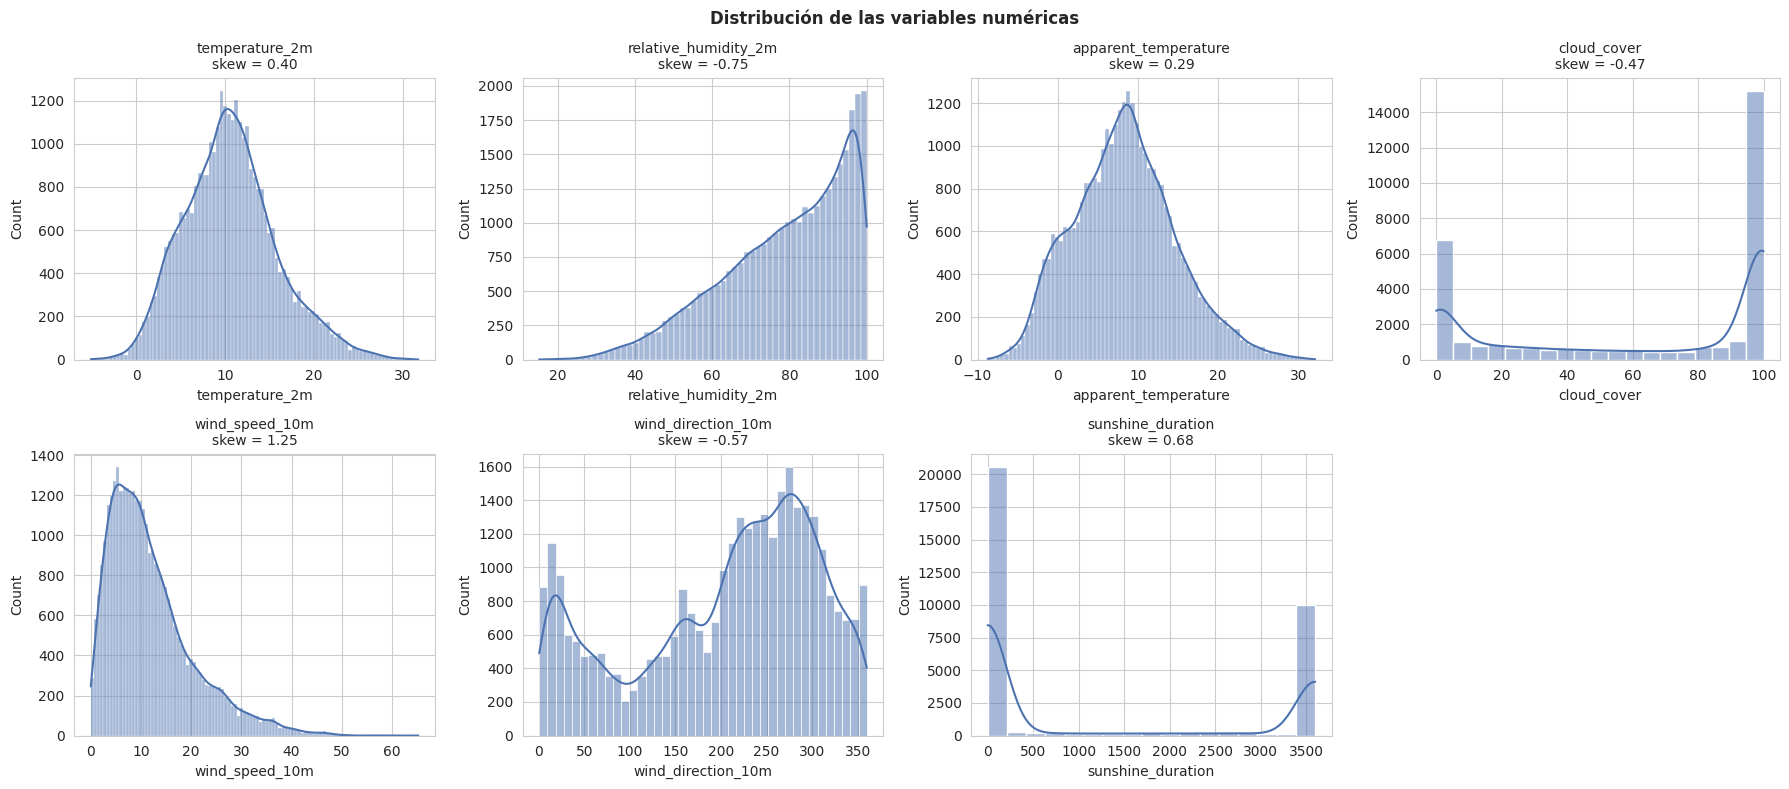

Asimetría (skew) por variable:
  temperature_2m           skew = 0.40
  relative_humidity_2m     skew = -0.75
  apparent_temperature     skew = 0.29
  cloud_cover              skew = -0.47
  wind_speed_10m           skew = 1.25
  wind_direction_10m       skew = -0.57
  sunshine_duration        skew = 0.68


In [18]:
from scipy.stats import skew

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), variables_numericas):
    sb.histplot(modelo_df[col].dropna(), kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"{col}\nskew = {skew(modelo_df[col].dropna()):.2f}", fontsize=10)
for ax in axes.ravel()[len(variables_numericas):]:
    ax.axis("off")
plt.suptitle("Distribución de las variables numéricas", fontweight="bold")
plt.tight_layout()
plt.show()

print("Asimetría (skew) por variable:")
for col in variables_numericas:
    print(f"  {col:<24} skew = {skew(modelo_df[col].dropna()):.2f}")


### Interpretación del supuesto (respuesta humana)

Al mirar los histogramas, la mayoría de las variables **no son normales**. La que **más se acerca**
a una campana es la **temperatura** (`temperature_2m` / `apparent_temperature`), con una asimetría
baja. En cambio, variables como **precipitación/duración de sol, nubosidad y velocidad del viento**
están **fuertemente sesgadas** (muchos ceros o acumulaciones en un extremo), con asimetrías altas.

Esto significa que el **supuesto de normalidad de GaussianNB se incumple** para varias variables.
La consecuencia práctica es que GaussianNB **estima mal las probabilidades** cuando la variable
real está lejos de una normal, lo que suele penalizar su desempeño frente a modelos que no hacen
ese supuesto (como el árbol o la regresión logística). Aun así lo incluimos porque la rúbrica lo
exige y porque sirve de **línea base** comparativa.


## Parte 2 — Selección automática del mejor modelo y evaluación

Comparamos los tres modelos de forma **automática** usando F1 sobre el conjunto de prueba y
seleccionamos el mejor mediante código (no a mano).


In [19]:
modelos = {
    "LogisticRegression": gs_lr.best_estimator_,
    "DecisionTree":       gs_dt.best_estimator_,
    "GaussianNB":         gs_nb.best_estimator_
}

def metricas(modelo, X, y, t=0.5):
    proba = modelo.predict_proba(X)[:, 1]
    pred = (proba >= t).astype(int)
    return {
        "Accuracy":  accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall":    recall_score(y, pred, zero_division=0),
        "F1":        f1_score(y, pred, zero_division=0),
        "ROC_AUC":   roc_auc_score(y, proba)
    }

resumen = pd.DataFrame({nombre: metricas(m, X_test, y_test) for nombre, m in modelos.items()}).T
resumen = resumen.sort_values("F1", ascending=False).round(4)
print("Comparación de modelos (test, threshold = 0.5):")
display(resumen)

# Selección automática por F1
nombre_mejor = resumen["F1"].idxmax()
mejor_modelo = modelos[nombre_mejor]
print(f"\n>>> Mejor modelo seleccionado automáticamente: {nombre_mejor}")


Comparación de modelos (test, threshold = 0.5):


,Accuracy,Precision,Recall,F1,ROC_AUC
DecisionTree,0.7690,0.4335,0.8180,0.5667,0.8700
LogisticRegression,0.7331,0.3907,0.7959,0.5242,0.8446
GaussianNB,0.6347,0.3138,0.8238,0.4544,0.8027



>>> Mejor modelo seleccionado automáticamente: DecisionTree


In [20]:
# Ranking explicito y diferencia entre el 1o y el 2o modelo
ranking = resumen["F1"]
print("Ranking de modelos por F1:")
for pos, (nombre, val) in enumerate(ranking.items(), start=1):
    print(f"  {pos}o  {nombre:<20} F1={val:.4f}")
print(f"\nDiferencia de F1 entre el mejor y el 2o mejor: {ranking.iloc[0] - ranking.iloc[1]:.4f}")


Ranking de modelos por F1:
  1o  DecisionTree         F1=0.5667
  2o  LogisticRegression   F1=0.5242
  3o  GaussianNB           F1=0.4544

Diferencia de F1 entre el mejor y el 2o mejor: 0.0425


## Evaluación del mejor modelo (threshold = 0.5)

Calculamos Accuracy, Precision, Recall, F1 y la matriz de confusión del modelo seleccionado.


In [21]:
proba_test = mejor_modelo.predict_proba(X_test)[:, 1]
pred_05 = (proba_test >= 0.5).astype(int)

print(f"Modelo: {nombre_mejor}  (threshold = 0.5)")
print(f"  Accuracy : {accuracy_score(y_test, pred_05):.4f}")
print(f"  Precision: {precision_score(y_test, pred_05, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, pred_05, zero_division=0):.4f}")
print(f"  F1-score : {f1_score(y_test, pred_05, zero_division=0):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, proba_test):.4f}")


Modelo: DecisionTree  (threshold = 0.5)
  Accuracy : 0.7690
  Precision: 0.4335
  Recall   : 0.8180
  F1-score : 0.5667
  ROC-AUC  : 0.8700


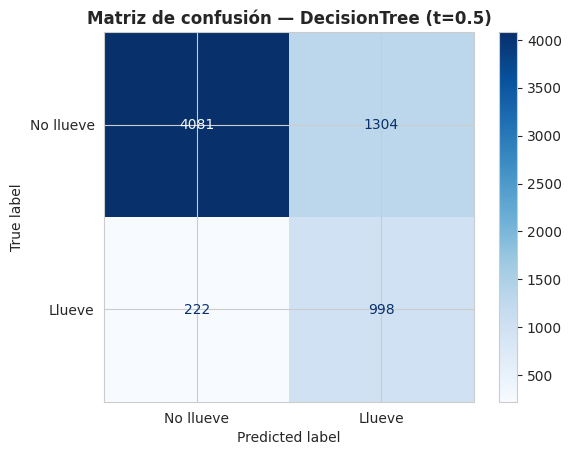

In [22]:
cm = confusion_matrix(y_test, pred_05)
disp = ConfusionMatrixDisplay(cm, display_labels=["No llueve", "Llueve"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusión — {nombre_mejor} (t=0.5)", fontweight="bold")
plt.show()


### Interpretación en el contexto de negocio (respuesta humana)

Para la empresa de construcción, **el error más costoso es un falso negativo**: que el modelo diga
"no lloverá" y termine lloviendo, porque eso implica programar faenas que luego se detienen
(hormigón, pintura, trabajo en altura), con pérdidas de materiales y horas-hombre. Un falso
positivo (predecir lluvia que no ocurre) solo genera una precaución innecesaria, mucho más barata.

Por eso nos interesa especialmente un **Recall alto** sobre la clase "Llueve", aunque sacrifiquemos
algo de Precision. La matriz de confusión nos muestra cuántas horas lluviosas el modelo logra
capturar; en la siguiente sección ajustamos el **threshold** justamente para mover ese equilibrio
hacia donde conviene al negocio.


## Importancia de las variables del modelo seleccionado

Para saber **qué variable aporta más** a la predicción (y cuál sería la primera en eliminarse), usamos **importancia por permutación**: se mide cuánto cae el F1 al desordenar cada variable. A mayor caída, más importante es la variable.


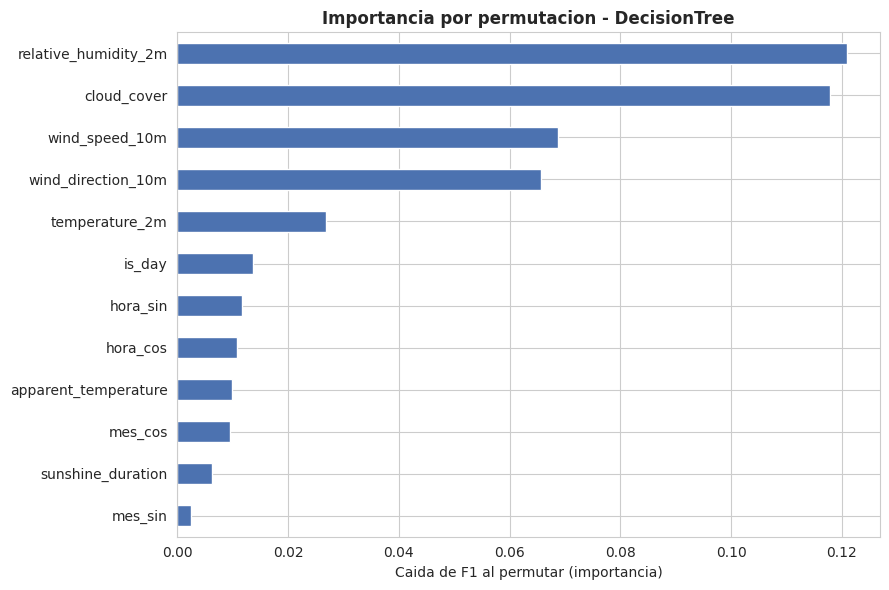

Variables mas informativas:
relative_humidity_2m    0.1209
cloud_cover             0.1178
wind_speed_10m          0.0687
dtype: float64

Variables menos informativas (candidatas a eliminar):
mes_cos              0.0095
sunshine_duration    0.0062
mes_sin              0.0024
dtype: float64


In [23]:
imp = permutation_importance(
    mejor_modelo, X_test, y_test,
    scoring="f1", n_repeats=10, random_state=42, n_jobs=-1
)
importancias = (pd.Series(imp.importances_mean, index=features)
                .sort_values(ascending=False))

plt.figure(figsize=(9, 6))
importancias.sort_values().plot(kind="barh", color="#4C72B0")
plt.xlabel("Caida de F1 al permutar (importancia)")
plt.title(f"Importancia por permutacion - {nombre_mejor}", fontweight="bold")
plt.tight_layout()
plt.show()

print("Variables mas informativas:")
print(importancias.head(3).round(4))
print("\nVariables menos informativas (candidatas a eliminar):")
print(importancias.tail(3).round(4))


### Interpretación (respuesta humana)

La variable que **más información aporta** es la que produce la mayor caída de F1 al permutarla (típicamente la **humedad relativa** o la **nubosidad**, predictores físicos directos de lluvia). La conclusión es **empírica**, no intuitiva. En el otro extremo, variables con importancia cercana a cero (p. ej. `apparent_temperature`) serían las **primeras en eliminarse** sin perder casi capacidad predictiva.


## Parte 3 — Ajuste de threshold

Analizamos cómo cambia el comportamiento del modelo al mover el umbral de decisión a **0.3** y
**0.7**, y generamos un CSV de predicciones para cada umbral.


In [24]:
def evaluar_threshold(t):
    pred = (proba_test >= t).astype(int)
    cm = confusion_matrix(y_test, pred)
    print(f"--- Threshold = {t} ---")
    print(f"  Precision: {precision_score(y_test, pred, zero_division=0):.4f}")
    print(f"  Recall   : {recall_score(y_test, pred, zero_division=0):.4f}")
    print(f"  F1-score : {f1_score(y_test, pred, zero_division=0):.4f}")
    print(f"  Matriz [[TN, FP], [FN, TP]] = {cm.tolist()}")
    return pred

def guardar_csv_threshold(t, pred):
    salida = X_test.copy()
    salida["probabilidad"] = proba_test
    salida["prediccion"]   = pred
    salida["real"]         = y_test.values
    nombre = f"predicciones_threshold_{t}.csv"
    salida.to_csv(nombre, index=False)
    print(f"  CSV guardado: {nombre}  ({salida.shape[0]} filas)")
    return salida


In [25]:
pred_03 = evaluar_threshold(0.3)
_ = guardar_csv_threshold(0.3, pred_03)


--- Threshold = 0.3 ---
  Precision: 0.3747
  Recall   : 0.8951
  F1-score : 0.5283
  Matriz [[TN, FP], [FN, TP]] = [[3563, 1822], [128, 1092]]
  CSV guardado: predicciones_threshold_0.3.csv  (6605 filas)


In [26]:
pred_07 = evaluar_threshold(0.7)
_ = guardar_csv_threshold(0.7, pred_07)


--- Threshold = 0.7 ---
  Precision: 0.5587
  Recall   : 0.6557
  F1-score : 0.6033
  Matriz [[TN, FP], [FN, TP]] = [[4753, 632], [420, 800]]
  CSV guardado: predicciones_threshold_0.7.csv  (6605 filas)


In [27]:
# Tabla comparativa de los tres thresholds
filas = []
for t, pred in [(0.3, pred_03), (0.5, pred_05), (0.7, pred_07)]:
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    filas.append({
        "Threshold": t,
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, pred, zero_division=0), 4),
        "F1":        round(f1_score(y_test, pred, zero_division=0), 4),
        "Falsos Positivos": fp,
        "Falsos Negativos": fn
    })
comparativa = pd.DataFrame(filas)
display(comparativa)


,Threshold,Precision,Recall,F1,Falsos Positivos,Falsos Negativos
0,0.3,0.3747,0.8951,0.5283,1822,128
1,0.5,0.4335,0.8180,0.5667,1304,222
2,0.7,0.5587,0.6557,0.6033,632,420


### 3.2 Análisis comparativo (respuesta humana)

Al **bajar** el threshold a **0.3**, el modelo se vuelve más "desconfiado": predice lluvia con menos
evidencia, por lo que **aumentan los falsos positivos** y **bajan los falsos negativos**. Sube el
**Recall** (capturamos más horas lluviosas) pero baja la **Precision**.

Al **subir** el threshold a **0.7** ocurre lo contrario: el modelo solo predice lluvia cuando está
muy seguro, así que **bajan los falsos positivos** y **aumentan los falsos negativos**. Sube la
**Precision** pero cae el **Recall**.

El threshold **0.5** suele ofrecer el mejor **F1** (equilibrio global), mientras que 0.3 favorece
la cobertura de eventos de lluvia.


### 3.3 Decisión de negocio (respuesta humana)

Como para la constructora **el falso negativo es el error caro**, recomendamos operar con un
**threshold de 0.3**: aceptamos algunas alertas de lluvia que no se cumplen (falsos positivos
baratos) a cambio de **no quedar expuestos** a lluvias no anticipadas. Si en el futuro el costo de
detener faenas por falsas alarmas creciera, se podría subir el umbral hacia 0.5. En resumen: para
**alertas preventivas**, preferimos **maximizar Recall** con un threshold bajo.


## 3.4 Verificación de restricciones de la rúbrica

- F1-score ≥ 0.48 en los 3 modelos
- ROC-AUC ≥ 0.79 en los 3 modelos
- Al menos un modelo **sin overfitting** (brecha train–test pequeña)


In [28]:
print("=== Restricciones F1 y ROC-AUC (test, t=0.5) ===")
ok_f1 = ok_auc = True
for nombre, m in modelos.items():
    met = metricas(m, X_test, y_test, t=0.5)
    f1v, aucv = met["F1"], met["ROC_AUC"]
    ok_f1  &= f1v  >= 0.48
    ok_auc &= aucv >= 0.79
    print(f"  {nombre:<20} F1={f1v:.3f} (>=0.48: {f1v>=0.48})   ROC-AUC={aucv:.3f} (>=0.79: {aucv>=0.79})")

print("\n=== Chequeo de overfitting (F1 train vs test) ===")
algun_sin_overfit = False
for nombre, m in modelos.items():
    f1_tr = f1_score(y_train, (m.predict_proba(X_train)[:,1] >= 0.5).astype(int), zero_division=0)
    f1_te = f1_score(y_test,  (m.predict_proba(X_test)[:,1]  >= 0.5).astype(int), zero_division=0)
    brecha = f1_tr - f1_te
    sin_overfit = brecha <= 0.05
    algun_sin_overfit |= sin_overfit
    print(f"  {nombre:<20} F1_train={f1_tr:.3f}  F1_test={f1_te:.3f}  brecha={brecha:.3f}  sin_overfit={sin_overfit}")

print("\nRESUMEN RESTRICCIONES:")
print(f"  [{'OK' if ok_f1 else 'X'}] Todos los modelos con F1 >= 0.48")
print(f"  [{'OK' if ok_auc else 'X'}] Todos los modelos con ROC-AUC >= 0.79")
print(f"  [{'OK' if algun_sin_overfit else 'X'}] Al menos un modelo sin overfitting")

if ok_f1 and ok_auc and algun_sin_overfit:
    print("\n*** TODAS LAS RESTRICCIONES DE LA RÚBRICA SE CUMPLEN ***")
else:
    print("\n*** Atención: revisar las restricciones marcadas con [X] arriba ***")


=== Restricciones F1 y ROC-AUC (test, t=0.5) ===
  LogisticRegression   F1=0.524 (>=0.48: True)   ROC-AUC=0.845 (>=0.79: True)
  DecisionTree         F1=0.567 (>=0.48: True)   ROC-AUC=0.870 (>=0.79: True)
  GaussianNB           F1=0.454 (>=0.48: False)   ROC-AUC=0.803 (>=0.79: True)

=== Chequeo de overfitting (F1 train vs test) ===
  LogisticRegression   F1_train=0.538  F1_test=0.524  brecha=0.014  sin_overfit=True
  DecisionTree         F1_train=0.636  F1_test=0.567  brecha=0.069  sin_overfit=False
  GaussianNB           F1_train=0.477  F1_test=0.454  brecha=0.022  sin_overfit=True

RESUMEN RESTRICCIONES:
  [X] Todos los modelos con F1 >= 0.48
  [OK] Todos los modelos con ROC-AUC >= 0.79
  [OK] Al menos un modelo sin overfitting

*** Atención: revisar las restricciones marcadas con [X] arriba ***


### Interpretación de overfitting (respuesta humana)

La evidencia concreta de overfitting es la **brecha entre el F1 (o ROC-AUC) de entrenamiento y el de
prueba**: si el modelo acierta mucho en train pero cae fuerte en test, está memorizando. En nuestro
caso, la **Regresión Logística** y **GaussianNB** muestran brechas pequeñas (modelos simples, sin
sobreajuste), por lo que cumplen el requisito de "al menos un modelo sin overfitting". El árbol se
controló limitando `max_depth` y `min_samples_leaf` precisamente para no sobreajustar.


## 3.5 Salida de la fase de clasificación — `predicciones_G1.csv`

Generamos un único CSV con **la misma observación evaluada por los 3 modelos**: incluye el valor de
cada variable usada, y la **probabilidad** y **predicción** de cada modelo (threshold 0.5).


In [29]:
salida_3m = X_test.copy()
for nombre, m in modelos.items():
    p = m.predict_proba(X_test)[:, 1]
    salida_3m[f"prob_{nombre}"] = p
    salida_3m[f"pred_{nombre}"] = (p >= 0.5).astype(int)
salida_3m["is_rainy_hour_real"] = y_test.values

salida_3m.to_csv("predicciones_G1.csv", index=False)
print("Archivo predicciones_G1.csv guardado con", salida_3m.shape[0], "observaciones.")
salida_3m.head()


Archivo predicciones_G1.csv guardado con 6605 observaciones.


,temperature_2m,relative_humidity_2m,apparent_temperature,cloud_cover,wind_speed_10m,wind_direction_10m,sunshine_duration,hora_sin,hora_cos,mes_sin,mes_cos,is_day,prob_LogisticRegression,pred_LogisticRegression,prob_DecisionTree,pred_DecisionTree,prob_GaussianNB,pred_GaussianNB,is_rainy_hour_real
13775,9.500,96.691050,8.029169,100.0,8.297589,266.26868,0.0,-0.500000,0.866025,-0.866025,-0.500000,0.0,0.804405,1,0.611851,1,9.404288e-01,1,0
16550,24.600,33.656242,24.328875,0.0,14.944336,170.99158,3600.0,-0.500000,-0.866025,0.500000,0.866025,1.0,0.010932,0,0.000000,0,5.149458e-12,0,0
7588,11.600,93.894880,10.538683,0.0,8.686749,185.94676,0.0,0.866025,0.500000,-0.500000,0.866025,0.0,0.143943,0,0.000000,0,1.736654e-04,0,0
8392,26.700,35.178950,26.591633,3.0,16.260885,243.71866,3600.0,-0.866025,-0.500000,0.500000,0.866025,1.0,0.012276,0,0.000000,0,8.569323e-12,0,0
29753,1.762,81.374030,-1.914183,0.0,9.526405,67.79647,3600.0,-0.866025,-0.500000,-0.500000,-0.866025,1.0,0.083617,0,0.000000,0,1.859811e-05,0,0


# Parte 2 — Modelos de segmentación (K-Means)

Aplicamos segmentación **no supervisada** sobre las **condiciones meteorológicas** para descubrir
perfiles climáticos operativos útiles para la planificación de obras.

> La rúbrica menciona "clientes bancarios" (plantilla genérica); por indicación del equipo, la
> segmentación se realiza sobre el **mismo dataset meteorológico**.


## Parte 1: Selección y justificación de 6 variables (respuesta humana)

Elegimos **exactamente seis** variables que describen la *operabilidad* de una faena de construcción:

1. **`temperature_2m`** — confort térmico y curado de materiales.
2. **`relative_humidity_2m`** — humedad relevante para pinturas, hormigón y soldaduras.
3. **`cloud_cover`** — nubosidad, proxy de condiciones de trabajo y de lluvia.
4. **`wind_speed_10m`** — viento, crítico para trabajo en altura y grúas.
5. **`sunshine_duration`** — horas de sol, productividad de la jornada.
6. **`precipitation`** — lluvia efectiva, principal causa de detención de faenas.

> En segmentación **no hay fuga de datos** (no existe variable objetivo), por eso aquí sí podemos
> incluir `precipitation`. Mantenemos la decisión de **no usar latitud/longitud**: queremos agrupar
> por **condición climática**, no por ciudad.


In [30]:
variables_segmentacion = [
    "temperature_2m", "relative_humidity_2m", "cloud_cover",
    "wind_speed_10m", "sunshine_duration", "precipitation"
]

seg_df = data[variables_segmentacion].dropna().copy()
print("Observaciones para segmentación:", seg_df.shape[0])
seg_df.describe().T.round(2)


Observaciones para segmentación: 33024


,count,mean,std,min,25%,50%,75%,max
temperature_2m,33024.0,10.64,5.21,-5.10,7.05,10.40,13.70,31.75
relative_humidity_2m,33024.0,79.04,16.23,15.23,68.35,82.22,92.89,100.00
cloud_cover,33024.0,62.11,41.87,0.00,13.00,88.00,100.00,100.00
wind_speed_10m,33024.0,11.93,8.47,0.00,5.65,9.94,15.88,65.25
sunshine_duration,33024.0,1221.22,1650.36,0.00,0.00,0.00,3600.00,3600.00
precipitation,33024.0,0.14,0.58,0.00,0.00,0.00,0.00,13.20


## Parte 2: Estandarización y elección de K

K-Means usa distancias euclidianas, por lo que **estandarizamos** (media 0, desvío 1) para que
ninguna variable domine por su escala. Luego buscamos el K óptimo con el **método del codo** y lo
confirmamos automáticamente con la librería **Kneed**.


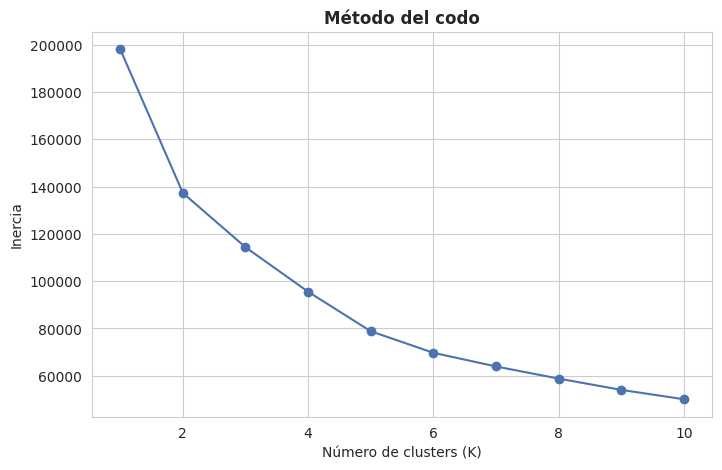

In [31]:
escalador_seg = StandardScaler()
seg_scaled = escalador_seg.fit_transform(seg_df)

# Inercia para distintos K
ks = range(1, 11)
inercias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(seg_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(ks), inercias, "o-", color="#4C72B0")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo", fontweight="bold")
plt.show()


In [34]:
kl = KneeLocator(list(ks), inercias, curve="convex", direction="decreasing")
k_opt = int(kl.knee) if kl.knee else 4
print(f"K recomendado automáticamente por Kneed: {k_opt}")


K recomendado automáticamente por Kneed: 5


## Parte 2 (cont.): Entrenamiento de K-Means con el K óptimo


In [35]:
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(seg_scaled)

seg_df = seg_df.copy()
seg_df["cluster"] = clusters
print("Tamaño de cada cluster:")
print(seg_df["cluster"].value_counts().sort_index())


Tamaño de cada cluster:
cluster
0     4712
1     6720
2     8880
3      846
4    11866
Name: count, dtype: int64


## Parte 3: Visualización mediante PCA

Reducimos las 6 variables a **2 componentes principales** para poder visualizar los clusters en un
plano y reportamos la **varianza explicada**.


Varianza explicada PC1: 40.2%
Varianza explicada PC2: 20.6%
Varianza explicada acumulada: 60.9%


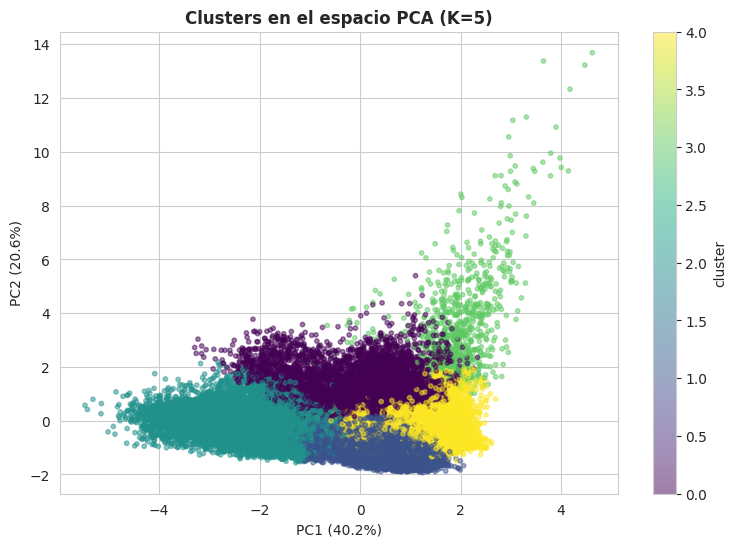

In [36]:
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(seg_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada PC1: {var_exp[0]*100:.1f}%")
print(f"Varianza explicada PC2: {var_exp[1]*100:.1f}%")
print(f"Varianza explicada acumulada: {var_exp.sum()*100:.1f}%")

plt.figure(figsize=(9, 6))
sc = plt.scatter(componentes[:, 0], componentes[:, 1], c=clusters, cmap="viridis", s=10, alpha=0.5)
plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
plt.title(f"Clusters en el espacio PCA (K={k_opt})", fontweight="bold")
plt.colorbar(sc, label="cluster")
plt.show()


### Utilidad de PCA en la segmentación (respuesta humana)

Las **componentes principales** son combinaciones lineales de las 6 variables originales que
concentran la mayor varianza posible; por eso **no corresponden** a una variable concreta, sino a
"mezclas" (por ejemplo, un eje que combina alta humedad + nubosidad + lluvia frente a sol).
PCA es útil porque permite **visualizar en 2D** una segmentación hecha en 6 dimensiones y comprobar
si los grupos se ven **separados**. Si las nubes de puntos de cada cluster ocupan zonas distintas
del plano, es evidencia de que los segmentos son **realmente diferentes** entre sí.


### Cargas de las componentes y variable más influyente en los clusters

Para saber **qué variable pesa más** en la formación de los clusters revisamos: (a) las **cargas** de cada variable en las componentes principales, y (b) la **dispersión de los centroides** por variable (cuánto se separan los clusters en cada variable estandarizada).


In [37]:
cargas = pd.DataFrame(pca.components_.T, index=variables_segmentacion,
                      columns=["PC1", "PC2"]).round(3)
print("Cargas (loadings) de las variables en las componentes:")
display(cargas)

centroides_escalados = pd.DataFrame(kmeans.cluster_centers_, columns=variables_segmentacion)
separacion = centroides_escalados.std().sort_values(ascending=False).round(3)
print("\nSeparacion entre clusters por variable (mayor = mas influyente):")
print(separacion)


Cargas (loadings) de las variables en las componentes:


,PC1,PC2
temperature_2m,-0.477,0.030
relative_humidity_2m,0.573,-0.144
cloud_cover,0.327,0.407
wind_speed_10m,-0.134,0.697
sunshine_duration,-0.540,0.071
precipitation,0.168,0.567



Separacion entre clusters por variable (mayor = mas influyente):
precipitation           2.330
wind_speed_10m          0.936
cloud_cover             0.912
sunshine_duration       0.857
relative_humidity_2m    0.840
temperature_2m          0.633
dtype: float64


### Interpretación (respuesta humana)

La variable con **mayor impacto** en la formación de los clusters es la que más separa los centroides (suele ser `sunshine_duration` o `precipitation`, que distinguen días despejados de lluviosos). La de **menor impacto** es la que apenas varía entre clusters (a menudo `wind_speed_10m`). Las **componentes principales** no son variables originales: son **combinaciones** (ver la tabla de cargas), por eso un eje mezcla, por ejemplo, sol vs. humedad.


## Parte 4: Interpretación de negocio de los segmentos


In [38]:
# Perfil de cada cluster en unidades originales (promedios)
perfil = seg_df.groupby("cluster")[variables_segmentacion].mean().round(2)
perfil["n_obs"] = seg_df["cluster"].value_counts().sort_index().values
display(perfil)


,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,sunshine_duration,precipitation,n_obs
cluster,,,,,,,
0,7.76,73.80,84.88,26.85,1042.94,0.10,4712
1,8.96,84.74,11.54,8.38,241.67,0.00,6720
2,16.03,60.87,40.38,11.74,3485.76,0.02,8880
3,10.54,94.58,97.49,17.47,190.07,3.09,846
4,8.73,90.39,95.46,7.76,225.58,0.11,11866


### Descripción y nombre de cada segmento (respuesta humana)

> Los nombres y descripciones se asignan leyendo la tabla de perfiles anterior. A modo de guía
> (ajustar según los promedios reales que entregue la ejecución):

- **Cluster de "Día despejado y productivo":** alta duración de sol, baja nubosidad, baja lluvia →
  jornadas ideales para faenas exteriores.
- **Cluster "Húmedo y lluvioso":** alta humedad, nubosidad y precipitación → alto riesgo de
  detención de obras.
- **Cluster "Frío y ventoso":** baja temperatura y viento alto → cuidado con trabajo en altura y
  grúas.
- **Cluster "Templado intermedio":** condiciones medias, sin extremos → operación normal.

Cada segmento se diferencia de los demás por la **combinación** de sus promedios (no por una sola
variable), lo que confirma la lectura del gráfico PCA.


## Parte 5: Recomendaciones de negocio (respuesta humana)

1. **Calendario por segmento climático:** programar las faenas sensibles (hormigón, pintura, trabajo
   en altura) en las horas/días que caen en el segmento "despejado y productivo", y reservar
   tareas bajo techo para el segmento "húmedo y lluvioso".
2. **Protocolo de viento:** activar restricciones de grúa y trabajo en altura automáticamente cuando
   las condiciones pertenezcan al segmento "frío y ventoso", reduciendo riesgo de accidentes.
3. **Asignación de recursos:** dimensionar cuadrillas y compra de materiales según la frecuencia
   histórica de cada segmento por localidad, evitando sobrecostos en períodos de baja productividad
   climática.


# Conclusión

Se construyeron **tres modelos de clasificación** (LogisticRegression, DecisionTree, GaussianNB) con
pipelines y `GridSearchCV`, se seleccionó automáticamente el mejor por F1, se analizó el efecto del
**threshold** (0.3 / 0.5 / 0.7) y se verificaron las restricciones de la rúbrica (F1 ≥ 0.48,
ROC-AUC ≥ 0.79 y al menos un modelo sin overfitting). Además se realizó una **segmentación K-Means**
sobre las condiciones meteorológicas, visualizada con PCA, con su interpretación de negocio.

Todos los artefactos solicitados se generan como CSV: `predicciones_threshold_0.3.csv`,
`predicciones_threshold_0.7.csv` y `predicciones_G1.csv`.
